In [ ]:
print("Khagrachhari Project")
title= "Integrating Indigenous Knowledge and Socio-ecological Adaptation to compound climatic hazards in Khagrachhari, Bangladesh"
print(title[1])
print(title)

Khagrachhari Project
n
Integrating Indigenous Knowledge and Socio-ecological Adaptation to compound climatic hazards in Khagrachhari, Bangladesh


2. Your Khagrachhari spatial layers

You have a surprisingly useful collection:

**Terrain**

Khagrachari_DEM
Khagrachari_Slope
Khagrachari_Aspect
Khagrachari_Hillslope

**Climate / hydrology**

Khagrachari_Rainfall
Khagrachhari_Rainfall_2001_2024
Khagrachari_temp
Khagrachari_soil_moisture

Vegetation / land cover

Khagrachari_NDVI
Khagrachari_LULC
Khagrachari_Forest_cover_2000
Khagrachari_Forest_loss

Hazard layers

Khagrachari_landslide
Khagrachari_flood
Khagrachari_drought
Khagrachari_Compound_hazard

In [ ]:
import rasterio
from pathlib import Path

folder = Path("Khagrachari ML Project")



for file in folder.glob("*.tif"):

    with rasterio.open(file) as src:

        print("\n-----------------------------")
        print("File:", file.name)
        print("CRS:", src.crs)
        print("Resolution:", src.res)
        print("Size:", src.width, "x", src.height)
        print("Bands:", src.count)
        print("Bounds:", src.bounds)
        print("NoData:", src.nodata)
with rasterio.open("Khagrachari_DEM.tif") as src:

    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Size:", src.width, "x", src.height)
    print("Bands:", src.count)
    print("Bounds:", src.bounds)
    print("NoData:", src.nodata)

CRS: EPSG:4326
Resolution: (0.0002694945852358564, 0.0002694945852358564)
Size: 1816 x 3888
Bands: 1
Bounds: BoundingBox(left=91.71023082677675, bottom=22.687266090058394, right=92.19963299356506, top=23.735061037455402)
NoData: None


In [ ]:
import rasterio
from pathlib import Path

folder = Path(".")

for file in folder.glob("*.tif"):

    with rasterio.open(file) as src:

        print("\n-----------------------------")
        print("File:", file.name)
        print("CRS:", src.crs)
        print("Resolution:", src.res)
        print("Size:", src.width, "x", src.height)
        print("Bands:", src.count)
        print("Bounds:", src.bounds)
        print("NoData:", src.nodata)


-----------------------------
File: Khagrachari_landslide.tif
CRS: EPSG:4326
Resolution: (0.0002694945852358564, 0.0002694945852358564)
Size: 1816 x 3888
Bands: 1
Bounds: BoundingBox(left=91.71023082677675, bottom=22.687266090058394, right=92.19963299356506, top=23.735061037455402)
NoData: None

-----------------------------
File: Khagrachari_Rainfall.tif
CRS: EPSG:4326
Resolution: (0.00026949458523585647, 0.00026949458523585647)
Size: 1816 x 3887
Bands: 1
Bounds: BoundingBox(left=91.71035482868814, bottom=22.687401658080574, right=92.19975699547645, top=23.73492711089235)
NoData: None

-----------------------------
File: Khagrachari_DEM.tif
CRS: EPSG:4326
Resolution: (0.0002694945852358564, 0.0002694945852358564)
Size: 1816 x 3888
Bands: 1
Bounds: BoundingBox(left=91.71023082677675, bottom=22.687266090058394, right=92.19963299356506, top=23.735061037455402)
NoData: None

-----------------------------
File: Khagrachari_LULC.tif
CRS: EPSG:4326
Resolution: (0.00026949458523585647, 0.000

Your current status

You've completed:

✅ Step 1 — File inventory

✅ Step 2 — CRS check

✅ Step 3 — Resolution check

✅ Step 4 — Dimensions/extent check

Now we're ready for:

Step 5 — Raster alignment + pixel-value inspection

Before we resample anything, let's make Python answer three questions:

Are the rasters actually aligned pixel-by-pixel?
What are their minimum and maximum values?
Are there hidden NaN/invalid pixels?

In [ ]:
# Raster alignment + pixel-value inspection

import rasterio
from pathlib import Path
import numpy as np

folder = Path(".")

for file in folder.glob("*.tif"):

    with rasterio.open(file) as src:
        data = src.read(1, masked=True)

        print("\n-----------------------------")
        print("File:", file.name)
        print("Shape:", data.shape)
        print("Min:", data.min())
        print("Max:", data.max())
        print("Mean:", data.mean())
        print("Masked pixels:", np.ma.count_masked(data))


-----------------------------
File: Khagrachari_landslide.tif
Shape: (3888, 1816)
Min: nan
Max: nan
Mean: nan
Masked pixels: 0

-----------------------------
File: Khagrachari_Rainfall.tif
Shape: (3887, 1816)
Min: nan
Max: nan
Mean: nan
Masked pixels: 0

-----------------------------
File: Khagrachari_DEM.tif
Shape: (3888, 1816)
Min: 0
Max: 619
Mean: 51.492677967676435
Masked pixels: 0

-----------------------------
File: Khagrachari_LULC.tif
Shape: (3888, 1816)
Min: 0
Max: 90
Mean: 6.432242095864832
Masked pixels: 0

-----------------------------
File: Khagrachari_Compound_hazard.tif
Shape: (3888, 1816)
Min: nan
Max: nan
Mean: nan
Masked pixels: 0

-----------------------------
File: Khagrachari_soil_moisture.tif
Shape: (3887, 1816)
Min: nan
Max: nan
Mean: nan
Masked pixels: 0

-----------------------------
File: Khagrachari_temp.tif
Shape: (3887, 1816)
Min: nan
Max: nan
Mean: nan
Masked pixels: 0

-----------------------------
File: Khagrachari_NDVI.tif
Shape: (3887, 1816)
Min: nan


Group A: (Containing values):

DEM

LULC

Forest_loss

Hillshade

Forest_cover_2000  

**Group B — NaN-containing layers**

Landslide

Rainfall

Compound_hazard

Soil_moisture

Temperature

NDVI

Aspect

Slope

Drought

Flood

In [ ]:
import rasterio
from pathlib import Path
import numpy as np

folder = Path(".")

for file in folder.glob("*.tif"):

    with rasterio.open(file) as src:
        data = src.read(1)

        nan_count = np.isnan(data).sum()
        total_pixels = data.size
        nan_percent = (nan_count / total_pixels) * 100

        print("\n-----------------------------")
        print("File:", file.name)
        print("Total pixels:", total_pixels)
        print("NaN pixels:", nan_count)
        print("NaN percentage:", round(nan_percent, 2), "%")


-----------------------------
File: Khagrachari_landslide.tif
Total pixels: 7060608
NaN pixels: 6548939
NaN percentage: 92.75 %

-----------------------------
File: Khagrachari_Rainfall.tif
Total pixels: 7058792
NaN pixels: 3435243
NaN percentage: 48.67 %

-----------------------------
File: Khagrachari_DEM.tif
Total pixels: 7060608
NaN pixels: 0
NaN percentage: 0.0 %

-----------------------------
File: Khagrachari_LULC.tif
Total pixels: 7060608
NaN pixels: 0
NaN percentage: 0.0 %

-----------------------------
File: Khagrachari_Compound_hazard.tif
Total pixels: 7060608
NaN pixels: 6548939
NaN percentage: 92.75 %

-----------------------------
File: Khagrachari_soil_moisture.tif
Total pixels: 7058792
NaN pixels: 3435243
NaN percentage: 48.67 %

-----------------------------
File: Khagrachari_temp.tif
Total pixels: 7058792
NaN pixels: 3435243
NaN percentage: 48.67 %

-----------------------------
File: Khagrachari_NDVI.tif
Total pixels: 7058792
NaN pixels: 3435243
NaN percentage: 48.6

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

files = [
    "Khagrachari_DEM.tif",
    "Khagrachari_Slope.tif",
    "Khagrachari_Rainfall.tif",
    "Khagrachari_NDVI.tif",
    "Khagrachari_landslide.tif"
]

for filename in files:

    with rasterio.open(filename) as src:
        data = src.read(1)

    valid = np.isfinite(data)

    plt.figure(figsize=(8, 6))
    plt.imshow(valid)
    plt.title(f"Valid pixels: {filename}")
    plt.axis("off")
    plt.show()

In [ ]:
import rasterio
import numpy as np

with rasterio.open("Khagrachari_landslide.tif") as src:
    data = src.read(1)

valid = data[np.isfinite(data)]

print("Number of valid pixels:", len(valid))
print("Minimum:", valid.min())
print("Maximum:", valid.max())
print("Mean:", valid.mean())

unique, counts = np.unique(valid, return_counts=True)

print("\nUnique values:")
for value, count in zip(unique, counts):
    print(value, "→", count)

Streaming output truncated to the last 5000 lines.
0.10206489096217686 → 1
0.10206863017876944 → 1
0.10207272152370878 → 1
0.10207585076226129 → 1
0.10207600285212201 → 1
0.10208146294487849 → 1
0.10208208194043902 → 1
0.10208731831179726 → 1
0.10208951898150974 → 1
0.10210485176245371 → 1
0.10210731456809574 → 1
0.10211065584288703 → 1
0.10211525819036696 → 1
0.1021208610402213 → 1
0.10212092997497985 → 1
0.10212124650478364 → 1
0.10212198901176453 → 1
0.10213220374584198 → 2
0.10213358466890124 → 1
0.10214488036367629 → 1
0.1021464999967151 → 1
0.10214933969444699 → 1
0.10215664594173432 → 1
0.10215666741265192 → 1
0.10215786292817859 → 1
0.10216089056332905 → 1
0.10216940247217814 → 1
0.10217140826384227 → 1
0.10217566748460133 → 1
0.10217757993539174 → 1
0.10217964871989355 → 1
0.10218500282234616 → 1
0.10218639466497634 → 1
0.1021941599527995 → 1
0.10219973500569662 → 1
0.10220253604518043 → 1
0.10220415448347728 → 1
0.10221008579466079 → 1
0.10221365257104237 → 1
0.10221435266865

In [ ]:
import rasterio
import numpy as np

with rasterio.open("Khagrachari_landslide.tif") as src:
    data = src.read(1)

valid = data[np.isfinite(data)]

print("Valid pixels:", len(valid))
print("Minimum:", np.min(valid))
print("Maximum:", np.max(valid))
print("Mean:", np.mean(valid))
print("Median:", np.median(valid))

print("\nPercentiles:")
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"{p}%:", np.percentile(valid, p))

Valid pixels: 511669
Minimum: -0.0664403859615326
Maximum: 0.2947835431390339
Mean: 0.0069185217648107715
Median: 0.00037931406233046756

Percentiles:
1%: -0.04834234085687002
5%: -0.038140316369798435
25%: -0.018300299835205067
50%: 0.00037931406233046756
75%: 0.02741745012866126
95%: 0.07100245382838774
99%: 0.10232476935715148


Real code starts here

In [ ]:
from pathlib import Path

folder = Path("Khagrachari ML Project")
folder = Path("/content")

print("Current directory:")
print(Path.cwd())

print("\nFolders/files here:")
for item in Path(".").iterdir():
    print(item)


from pathlib import Path

tifs = list(Path(".").rglob("*.tif"))

print("Number of TIFF files found:", len(tifs))

for f in tifs:
    print(f)


Current directory:
/content

Folders/files here:
.config
Khagrachari_landslide.tif
Khagrachari_Rainfall.tif
Khagrachari_DEM.tif
Khagrachari_LULC.tif
Khagrachari_Compound_hazard.tif
Khagrachari_soil_moisture.tif
Khagrachari_temp.tif
Khagrachari_NDVI.tif
Khagrachari_Forest_loss.tif
Khagrachari_Hillshade.tif
Khagrachari_Aspect.tif
Khagrachari_Slope.tif
Khagrachari_Forest_cover_2000.tif
Khagrachari_drought.tif
Khagrachari_flood.tif
sample_data
Number of TIFF files found: 15
Khagrachari_landslide.tif
Khagrachari_Rainfall.tif
Khagrachari_DEM.tif
Khagrachari_LULC.tif
Khagrachari_Compound_hazard.tif
Khagrachari_soil_moisture.tif
Khagrachari_temp.tif
Khagrachari_NDVI.tif
Khagrachari_Forest_loss.tif
Khagrachari_Hillshade.tif
Khagrachari_Aspect.tif
Khagrachari_Slope.tif
Khagrachari_Forest_cover_2000.tif
Khagrachari_drought.tif
Khagrachari_flood.tif


In [ ]:
import rasterio
from pathlib import Path
import numpy as np
import pandas as pd

folder = Path("/content")

records = []

for file in sorted(folder.glob("*.tif")):

    with rasterio.open(file) as src:

        data = src.read(1)

        # Only finite values
        valid = data[np.isfinite(data)]

        records.append({
            "Layer": file.name,
            "Rows": src.height,
            "Cols": src.width,
            "CRS": str(src.crs),
            "Resolution_X": src.res[0],
            "Resolution_Y": src.res[1],
            "Valid_pixels": len(valid),
            "NaN_%": 100 * np.isnan(data).sum() / data.size,
            "Min": np.min(valid) if len(valid) else np.nan,
            "Max": np.max(valid) if len(valid) else np.nan,
            "Mean": np.mean(valid) if len(valid) else np.nan,
            "Median": np.median(valid) if len(valid) else np.nan
        })

audit = pd.DataFrame(records)

pd.set_option("display.max_columns", None)
display(audit)

,Layer,Rows,Cols,CRS,Resolution_X,Resolution_Y,Valid_pixels,NaN_%,Min,Max,Mean,Median
0,Khagrachari_Aspect.tif,3888,1816,EPSG:4326,0.000269,0.000269,3611533,48.849547,-0.0,359.107391,175.923447,180.000000
1,Khagrachari_Compound_hazard.tif,3888,1816,EPSG:4326,0.000269,0.000269,511669,92.753188,0.262325,0.332197,0.297355,0.297881
2,Khagrachari_DEM.tif,3888,1816,EPSG:4326,0.000269,0.000269,7060608,0.000000,0,619,51.492678,34.000000
3,Khagrachari_Forest_cover_2000.tif,3887,1816,EPSG:4326,0.000269,0.000269,7058792,0.000000,0,100,27.525739,0.000000
4,Khagrachari_Forest_loss.tif,3887,1816,EPSG:4326,0.000269,0.000269,7058792,0.000000,0,24,1.173912,0.000000
5,Khagrachari_Hillshade.tif,3888,1816,EPSG:4326,0.000269,0.000269,7060608,0.000000,0,255,92.376743,124.000000
6,Khagrachari_LULC.tif,3888,1816,EPSG:4326,0.000269,0.000269,7060608,0.000000,0,90,6.432242,10.000000
7,Khagrachari_NDVI.tif,3887,1816,EPSG:4326,0.000269,0.000269,3623549,48.666160,0.348034,0.827475,0.710928,0.716850
8,Khagrachari_Rainfall.tif,3887,1816,EPSG:4326,0.000269,0.000269,3623549,48.666160,7.937809,8.769188,8.360476,8.363909
9,Khagrachari_Slope.tif,3888,1816,EPSG:4326,0.000269,0.000269,3611533,48.849547,0.0,72.694496,8.556087,7.061677


In [ ]:
import rasterio
from pathlib import Path
import numpy as np
import pandas as pd

folder = Path("/content")

records = []

for file in sorted(folder.glob("*.tif")):

    with rasterio.open(file) as src:

        data = src.read(1)

        # Only finite values
        valid = data[np.isfinite(data)]

        records.append({
            "Layer": file.name,
            "Rows": src.height,
            "Cols": src.width,
            "CRS": str(src.crs),
            "Resolution_X": src.res[0],
            "Resolution_Y": src.res[1],
            "Valid_pixels": len(valid),
            "NaN_%": 100 * np.isnan(data).sum() / data.size,
            "Min": np.min(valid) if len(valid) else np.nan,
            "Max": np.max(valid) if len(valid) else np.nan,
            "Mean": np.mean(valid) if len(valid) else np.nan,
            "Median": np.median(valid) if len(valid) else np.nan
        })

audit = pd.DataFrame(records)

pd.set_option("display.max_columns", None)
display(audit)

,Layer,Rows,Cols,CRS,Resolution_X,Resolution_Y,Valid_pixels,NaN_%,Min,Max,Mean,Median
0,Khagrachari_Aspect.tif,3888,1816,EPSG:4326,0.000269,0.000269,3611533,48.849547,-0.0,359.107391,175.923447,180.000000
1,Khagrachari_Compound_hazard.tif,3888,1816,EPSG:4326,0.000269,0.000269,511669,92.753188,0.262325,0.332197,0.297355,0.297881
2,Khagrachari_DEM.tif,3888,1816,EPSG:4326,0.000269,0.000269,7060608,0.000000,0,619,51.492678,34.000000
3,Khagrachari_Forest_cover_2000.tif,3887,1816,EPSG:4326,0.000269,0.000269,7058792,0.000000,0,100,27.525739,0.000000
4,Khagrachari_Forest_loss.tif,3887,1816,EPSG:4326,0.000269,0.000269,7058792,0.000000,0,24,1.173912,0.000000
5,Khagrachari_Hillshade.tif,3888,1816,EPSG:4326,0.000269,0.000269,7060608,0.000000,0,255,92.376743,124.000000
6,Khagrachari_LULC.tif,3888,1816,EPSG:4326,0.000269,0.000269,7060608,0.000000,0,90,6.432242,10.000000
7,Khagrachari_NDVI.tif,3887,1816,EPSG:4326,0.000269,0.000269,3623549,48.666160,0.348034,0.827475,0.710928,0.716850
8,Khagrachari_Rainfall.tif,3887,1816,EPSG:4326,0.000269,0.000269,3623549,48.666160,7.937809,8.769188,8.360476,8.363909
9,Khagrachari_Slope.tif,3888,1816,EPSG:4326,0.000269,0.000269,3611533,48.849547,0.0,72.694496,8.556087,7.061677


In [ ]:
from pathlib import Path

tifs = list(Path(".").rglob("*.tif"))

print("Number of TIFF files found:", len(tifs))

for f in tifs:
    print(f)

Number of TIFF files found: 15
Khagrachari_landslide.tif
Khagrachari_Rainfall.tif
Khagrachari_DEM.tif
Khagrachari_LULC.tif
Khagrachari_Compound_hazard.tif
Khagrachari_soil_moisture.tif
Khagrachari_temp.tif
Khagrachari_NDVI.tif
Khagrachari_Forest_loss.tif
Khagrachari_Hillshade.tif
Khagrachari_Aspect.tif
Khagrachari_Slope.tif
Khagrachari_Forest_cover_2000.tif
Khagrachari_drought.tif
Khagrachari_flood.tif


In [ ]:
#Checking exact spatial alignment
import rasterio
from pathlib import Path

folder = Path("/content")

files = sorted(folder.glob("*.tif"))

reference_file = folder / "Khagrachari_DEM.tif"

with rasterio.open(reference_file) as ref:
    print("REFERENCE:", reference_file.name)
    print("CRS:", ref.crs)
    print("Shape:", (ref.height, ref.width))
    print("Resolution:", ref.res)
    print("Transform:")
    print(ref.transform)
    print("Bounds:")
    print(ref.bounds)

    reference_transform = ref.transform
    reference_crs = ref.crs
    reference_shape = (ref.height, ref.width)

print("\n--- ALIGNMENT CHECK ---")

for file in files:

    with rasterio.open(file) as src:

        same_crs = src.crs == reference_crs
        same_shape = (src.height, src.width) == reference_shape
        same_transform = src.transform == reference_transform

        print(
            f"{file.name:40} | "
            f"CRS={same_crs} | "
            f"Shape={same_shape} | "
            f"Transform={same_transform}"
        )

REFERENCE: Khagrachari_DEM.tif
CRS: EPSG:4326
Shape: (3888, 1816)
Resolution: (0.0002694945852358564, 0.0002694945852358564)
Transform:
| 0.00, 0.00, 91.71|
| 0.00,-0.00, 23.74|
| 0.00, 0.00, 1.00|
Bounds:
BoundingBox(left=91.71023082677675, bottom=22.687266090058394, right=92.19963299356506, top=23.735061037455402)

--- ALIGNMENT CHECK ---
Khagrachari_Aspect.tif                   | CRS=True | Shape=True | Transform=True
Khagrachari_Compound_hazard.tif          | CRS=True | Shape=True | Transform=True
Khagrachari_DEM.tif                      | CRS=True | Shape=True | Transform=True
Khagrachari_Forest_cover_2000.tif        | CRS=True | Shape=False | Transform=False
Khagrachari_Forest_loss.tif              | CRS=True | Shape=False | Transform=False
Khagrachari_Hillshade.tif                | CRS=True | Shape=True | Transform=True
Khagrachari_LULC.tif                     | CRS=True | Shape=True | Transform=False
Khagrachari_NDVI.tif                     | CRS=True | Shape=False | Transform=

In [ ]:
import rasterio
from pathlib import Path

folder = Path("/content")

reference = folder / "Khagrachari_DEM.tif"

with rasterio.open(reference) as src:
    print("REFERENCE GRID")
    print("-------------------------")
    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Transform:")
    print(src.transform)
    print("Bounds:", src.bounds)

REFERENCE GRID
-------------------------
CRS: EPSG:4326
Width: 1816
Height: 3888
Transform:
| 0.00, 0.00, 91.71|
| 0.00,-0.00, 23.74|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=91.71023082677675, bottom=22.687266090058394, right=92.19963299356506, top=23.735061037455402)


In [ ]:
import rasterio
from pathlib import Path

folder = Path("/content")

# Corrected filename: removed the extra '.tif'
reference = folder / "Khagrachari_Rainfall.tif"

with rasterio.open(reference) as src:
    print("REFERENCE GRID")
    print("-------------------------")
    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Transform:")
    print(src.transform)
    print("Bounds:", src.bounds)

REFERENCE GRID
-------------------------
CRS: EPSG:4326
Width: 1816
Height: 3887
Transform:
| 0.00, 0.00, 91.71|
| 0.00,-0.00, 23.73|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=91.71035482868814, bottom=22.687401658080574, right=92.19975699547645, top=23.73492711089235)


In [ ]:
import rasterio
from pathlib import Path

folder = Path("/content")
reference = folder / "Khagrachari_DEM.tif"

with rasterio.open(reference) as ref:

    for file in sorted(folder.glob("*.tif")):

        with rasterio.open(file) as src:

            same_crs = src.crs == ref.crs
            same_shape = (src.width == ref.width and
                          src.height == ref.height)
            same_transform = src.transform == ref.transform

            print(
                f"{file.name:35} | "
                f"CRS={same_crs} | "
                f"Shape={same_shape} | "
                f"Transform={same_transform}"
            )




Khagrachari_Aspect.tif              | CRS=True | Shape=True | Transform=True
Khagrachari_Compound_hazard.tif     | CRS=True | Shape=True | Transform=True
Khagrachari_DEM.tif                 | CRS=True | Shape=True | Transform=True
Khagrachari_Forest_cover_2000.tif   | CRS=True | Shape=False | Transform=False
Khagrachari_Forest_loss.tif         | CRS=True | Shape=False | Transform=False
Khagrachari_Hillshade.tif           | CRS=True | Shape=True | Transform=True
Khagrachari_LULC.tif                | CRS=True | Shape=True | Transform=False
Khagrachari_NDVI.tif                | CRS=True | Shape=False | Transform=False
Khagrachari_Rainfall.tif            | CRS=True | Shape=False | Transform=False
Khagrachari_Slope.tif               | CRS=True | Shape=True | Transform=True
Khagrachari_drought.tif             | CRS=True | Shape=False | Transform=False
Khagrachari_flood.tif               | CRS=True | Shape=True | Transform=True
Khagrachari_landslide.tif           | CRS=True | Shape=True | Tra

In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path

input_folder = Path("/content")
output_folder = Path("/content/Khagrachari_aligned")

output_folder.mkdir(exist_ok=True)

reference_path = input_folder / "Khagrachari_DEM.tif"

with rasterio.open(reference_path) as ref:

    reference_crs = ref.crs
    reference_transform = ref.transform
    reference_width = ref.width
    reference_height = ref.height

    print("Reference grid:")
    print("CRS:", reference_crs)
    print("Shape:", reference_height, reference_width)
    print("Transform:", reference_transform)

print("\nOutput folder created:")
print(output_folder)

Reference grid:
CRS: EPSG:4326
Shape: 3888 1816
Transform: | 0.00, 0.00, 91.71|
| 0.00,-0.00, 23.74|
| 0.00, 0.00, 1.00|

Output folder created:
/content/Khagrachari_aligned


In [ ]:
#Create the alignment function
import rasterio
from rasterio.warp import reproject, Resampling
from pathlib import Path

input_folder = Path("/content")
output_folder = Path("/content/Khagrachari_aligned")

reference_path = input_folder / "Khagrachari_DEM.tif"


def align_raster(input_path, output_path, reference_path, resampling_method):

    # Open reference raster
    with rasterio.open(reference_path) as ref:

        # Open input raster
        with rasterio.open(input_path) as src:

            # Create output profile based on reference grid
            profile = src.profile.copy()

            profile.update({
                "crs": ref.crs,
                "transform": ref.transform,
                "width": ref.width,
                "height": ref.height
            })

            # Create aligned raster
            with rasterio.open(output_path, "w", **profile) as dst:

                reproject(
                    source=rasterio.band(src, 1),
                    destination=rasterio.band(dst, 1),

                    src_transform=src.transform,
                    src_crs=src.crs,

                    dst_transform=ref.transform,
                    dst_crs=ref.crs,

                    resampling=resampling_method
                )

In [ ]:
#Defining layers:

continuous_layers = [
    "Khagrachari_Forest_cover_2000.tif",
    "Khagrachari_Forest_loss.tif",
    "Khagrachari_NDVI.tif",
    "Khagrachari_Rainfall.tif",
    "Khagrachari_drought.tif",
    "Khagrachari_soil_moisture.tif",
    "Khagrachari_temp.tif"
]

categorical_layers = [
    "Khagrachari_LULC.tif"
]


In [ ]:
#Aligning continuous layers:

for filename in continuous_layers:

    input_path = input_folder / filename
    output_path = output_folder / filename

    align_raster(
        input_path,
        output_path,
        reference_path,
        Resampling.bilinear
    )

    print("Aligned:", filename)

Aligned: Khagrachari_Forest_cover_2000.tif
Aligned: Khagrachari_Forest_loss.tif
Aligned: Khagrachari_NDVI.tif
Aligned: Khagrachari_Rainfall.tif
Aligned: Khagrachari_drought.tif
Aligned: Khagrachari_soil_moisture.tif
Aligned: Khagrachari_temp.tif


In [ ]:
#Lulc alignment separately:

for filename in categorical_layers:

    input_path = input_folder / filename
    output_path = output_folder / filename

    align_raster(
        input_path,
        output_path,
        reference_path,
        Resampling.nearest
    )

    print("Aligned:", filename)

Aligned: Khagrachari_LULC.tif


In [ ]:
#Verification of Raster Layers
import rasterio
from pathlib import Path

aligned_folder = Path("/content/Khagrachari_aligned")
reference_path = Path("/content/Khagrachari_DEM.tif")

with rasterio.open(reference_path) as ref:

    print("REFERENCE")
    print("Shape:", (ref.height, ref.width))
    print("CRS:", ref.crs)
    print("Transform:", ref.transform)
    print("\nALIGNMENT CHECK")
    print("-" * 80)

    for file in sorted(aligned_folder.glob("*.tif")):

        with rasterio.open(file) as src:

            same_crs = src.crs == ref.crs
            same_shape = (
                src.height == ref.height and
                src.width == ref.width
            )
            same_transform = src.transform == ref.transform

            print(
                f"{file.name:35} | "
                f"CRS={same_crs} | "
                f"Shape={same_shape} | "
                f"Transform={same_transform}"
            )

REFERENCE
Shape: (3888, 1816)
CRS: EPSG:4326
Transform: | 0.00, 0.00, 91.71|
| 0.00,-0.00, 23.74|
| 0.00, 0.00, 1.00|

ALIGNMENT CHECK
--------------------------------------------------------------------------------
Khagrachari_Forest_cover_2000.tif   | CRS=True | Shape=True | Transform=True
Khagrachari_Forest_loss.tif         | CRS=True | Shape=True | Transform=True
Khagrachari_LULC.tif                | CRS=True | Shape=True | Transform=True
Khagrachari_NDVI.tif                | CRS=True | Shape=True | Transform=True
Khagrachari_Rainfall.tif            | CRS=True | Shape=True | Transform=True
Khagrachari_drought.tif             | CRS=True | Shape=True | Transform=True
Khagrachari_soil_moisture.tif       | CRS=True | Shape=True | Transform=True
Khagrachari_temp.tif                | CRS=True | Shape=True | Transform=True


GEE-derived TIFFs

      ↓
Raster audit     
            ✅
      ↓
CRS / extent / resolution
   ✅
      ↓
Reference DEM grid   
        ✅
      ↓

Raster alignment   
          ✅
      ↓
          WE ARE HERE
          
      ↓
Masking + valid pixels
      ← NEXT
      ↓
Feature extraction


      ↓
ML DataFrame

      ↓
X / y
      ↓
ML models

In [ ]:
#Solid Valid-Pixel masking:

import rasterio
import numpy as np
from pathlib import Path

aligned_folder = Path("/content/Khagrachari_aligned")

layers = [
    "Khagrachari_DEM.tif",
    "Khagrachari_Slope.tif",
    "Khagrachari_Aspect.tif",
    "Khagrachari_Rainfall.tif",
    "Khagrachari_NDVI.tif",
    "Khagrachari_temp.tif",
    "Khagrachari_soil_moisture.tif",
    "Khagrachari_Forest_loss.tif",
    "Khagrachari_Forest_cover_2000.tif",
    "Khagrachari_LULC.tif"
]

valid_mask = None

for filename in layers:

    path = aligned_folder / filename

    # DEM, slope, aspect etc. are still in /content
    if not path.exists():
        path = Path("/content") / filename

    with rasterio.open(path) as src:

        data = src.read(1)

        # Valid = finite number
        layer_valid = np.isfinite(data)

        if valid_mask is None:
            valid_mask = layer_valid
        else:
            valid_mask &= layer_valid

        print(
            f"{filename:35} "
            f"valid pixels = {layer_valid.sum():,}"
        )

print("\n" + "=" * 60)
print("COMMON VALID PIXELS")
print("=" * 60)

print("Total pixels:", valid_mask.size)
print("Common valid pixels:", valid_mask.sum())
print(
    "Common valid percentage:",
    round(100 * valid_mask.mean(), 2),
    "%"
)

Khagrachari_DEM.tif                 valid pixels = 7,060,608
Khagrachari_Slope.tif               valid pixels = 3,611,533
Khagrachari_Aspect.tif              valid pixels = 3,611,533
Khagrachari_Rainfall.tif            valid pixels = 3,616,909
Khagrachari_NDVI.tif                valid pixels = 3,616,909
Khagrachari_temp.tif                valid pixels = 3,616,909
Khagrachari_soil_moisture.tif       valid pixels = 3,616,909
Khagrachari_Forest_loss.tif         valid pixels = 7,060,608
Khagrachari_Forest_cover_2000.tif   valid pixels = 7,060,608
Khagrachari_LULC.tif                valid pixels = 7,060,608

COMMON VALID PIXELS
Total pixels: 7060608
Common valid pixels: 3611073
Common valid percentage: 51.14 %


geospatial alignment → spatial masking → pixel-level feature engineering → ML dataset construction → model training → spatial prediction.

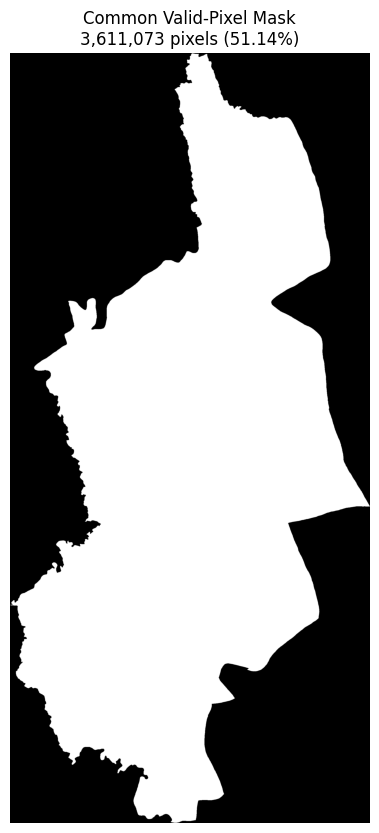

In [ ]:
#Making the mask visible:

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

aligned_folder = Path("/content/Khagrachari_aligned")
reference_path = Path("/content/Khagrachari_DEM.tif")

# Recreate common valid mask
layers = [
    "Khagrachari_DEM.tif",
    "Khagrachari_Slope.tif",
    "Khagrachari_Aspect.tif",
    "Khagrachari_Rainfall.tif",
    "Khagrachari_NDVI.tif",
    "Khagrachari_temp.tif",
    "Khagrachari_soil_moisture.tif",
    "Khagrachari_Forest_loss.tif",
    "Khagrachari_Forest_cover_2000.tif",
    "Khagrachari_LULC.tif"
]

valid_mask = None

for filename in layers:

    path = aligned_folder / filename

    if not path.exists():
        path = Path("/content") / filename

    with rasterio.open(path) as src:
        data = src.read(1)
        layer_valid = np.isfinite(data)

        if valid_mask is None:
            valid_mask = layer_valid
        else:
            valid_mask &= layer_valid

# Plot mask
plt.figure(figsize=(8, 10))

plt.imshow(valid_mask, cmap="gray")

plt.title(
    f"Common Valid-Pixel Mask\n"
    f"{valid_mask.sum():,} pixels "
    f"({100 * valid_mask.mean():.2f}%)"
)

plt.axis("off")
plt.show()

In [ ]:
#ML Data frames:

import rasterio
import numpy as np
import pandas as pd
from pathlib import Path

aligned_folder = Path("/content/Khagrachari_aligned")

predictors = [
    "Khagrachari_DEM.tif",
    "Khagrachari_Slope.tif",
    "Khagrachari_Aspect.tif",
    "Khagrachari_Rainfall.tif",
    "Khagrachari_NDVI.tif",
    "Khagrachari_temp.tif",
    "Khagrachari_soil_moisture.tif",
    "Khagrachari_Forest_loss.tif",
    "Khagrachari_Forest_cover_2000.tif",
    "Khagrachari_LULC.tif"
]

data = {}

for filename in predictors:

    path = aligned_folder / filename

    # Check if the file exists in the aligned folder, otherwise assume it's in the original /content folder
    if not path.exists():
        path = Path("/content") / filename

    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")

        # Convert raster NoData to NaN
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan

        data[filename.replace("Khagrachari_", "").replace(".tif", "")] = arr.flatten()

df = pd.DataFrame(data)

print("Initial DataFrame shape:")
print(df.shape)

print("\nMissing values:")
print(df.isna().sum())

print("\nFirst 5 rows:")
display(df.head())

Initial DataFrame shape:
(7060608, 10)

Missing values:
DEM                        0
Slope                3449075
Aspect               3449075
Rainfall             3443699
NDVI                 3443699
temp                 3443699
soil_moisture        3443699
Forest_loss                0
Forest_cover_2000          0
LULC                       0
dtype: int64

First 5 rows:


,DEM,Slope,Aspect,Rainfall,NDVI,temp,soil_moisture,Forest_loss,Forest_cover_2000,LULC
0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0


In [ ]:
df_clean = df.dropna().copy()

print("Original pixels:", len(df))
print("Complete ML pixels:", len(df_clean))

print("\nFinal shape:")
print(df_clean.shape)

Original pixels: 7060608
Complete ML pixels: 3611073

Final shape:
(3611073, 10)


And then your project becomes genuinely GeoAI

We'll progressively move through:

Phase 1 — Raster engineering ✅
CRS, resolution, extent, alignment, masking

Phase 2 — Feature extraction ← YOU ARE HERE

Phase 3 — ML DataFrame

Phase 4 — EDA

Phase 5 — Feature engineering

Phase 6 — Spatial sampling

Phase 7 — ML modelling

Phase 8 — Model interpretation

Phase 9 — Return predictions to raster

Phase 10 — Produce the final Khagrachhari GeoAI map

Phase 11 — GitHub repository

Phase 12 — Portfolio/FB/LinkedIn presentation

And alongside this, we can start your Deep Learning fundamentals without letting DL derail the project.

In [ ]:
#Quality check before EDA:

print("Missing values after cleaning:")
print(df_clean.isna().sum())

print("\nData types:")
print(df_clean.dtypes)

print("\nSummary statistics:")
display(df_clean.describe().T)

Missing values after cleaning:
DEM                  0
Slope                0
Aspect               0
Rainfall             0
NDVI                 0
temp                 0
soil_moisture        0
Forest_loss          0
Forest_cover_2000    0
LULC                 0
dtype: int64

Data types:
DEM                  float32
Slope                float32
Aspect               float32
Rainfall             float32
NDVI                 float32
temp                 float32
soil_moisture        float32
Forest_loss          float32
Forest_cover_2000    float32
LULC                 float32
dtype: object

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
DEM,3611073.0,100.283241,62.235760,9.000000,57.000000,83.000000,124.000000,619.000000
Slope,3611073.0,8.556204,6.216870,0.000000,3.839349,7.061740,11.834646,72.694496
Aspect,3611073.0,175.924850,100.913795,-0.000000,90.000000,180.000000,262.538513,359.107391
Rainfall,3611073.0,8.360456,0.272201,7.937809,8.231960,8.363909,8.455630,8.769188
NDVI,3611073.0,0.710922,0.054309,0.348034,0.684447,0.716767,0.746189,0.827475
temp,3611073.0,24.557251,0.640726,23.953815,24.352713,24.615904,24.788521,25.147007
soil_moisture,3611073.0,14.895553,0.462018,14.307272,14.621492,14.893608,15.141450,15.844061
Forest_loss,3611073.0,2.283582,5.034935,0.000000,0.000000,0.000000,1.000000,24.000000
Forest_cover_2000,3611073.0,53.627686,27.964071,0.000000,34.000000,62.000000,77.000000,100.000000
LULC,3611073.0,12.533325,8.599123,10.000000,10.000000,10.000000,10.000000,90.000000


In [ ]:
# ============================================
# FEATURE DIAGNOSTIC CHECK
# ============================================

#Why we're doing this

#This isn't just a coding exercise.
#We're asking:
#"Does the dataset make geographical sense before I allow a machine-learning algorithm to learn from it?"

for col in df_clean.columns:

    print("\n" + "=" * 50)
    print(col)

    print("Unique values:", df_clean[col].nunique())

    if df_clean[col].nunique() <= 30:
        print("Values:")
        print(df_clean[col].value_counts().sort_index())

    else:
        print("Min:", df_clean[col].min())
        print("Max:", df_clean[col].max())


# Explicit checks
print("\n" + "=" * 50)
print("ASPECT CHECK")
print("Min:", df_clean["Aspect"].min())
print("Max:", df_clean["Aspect"].max())

print("\n" + "=" * 50)
print("LULC CHECK")
print(df_clean["LULC"].value_counts().sort_index())

NameError: name 'df_clean' is not defined

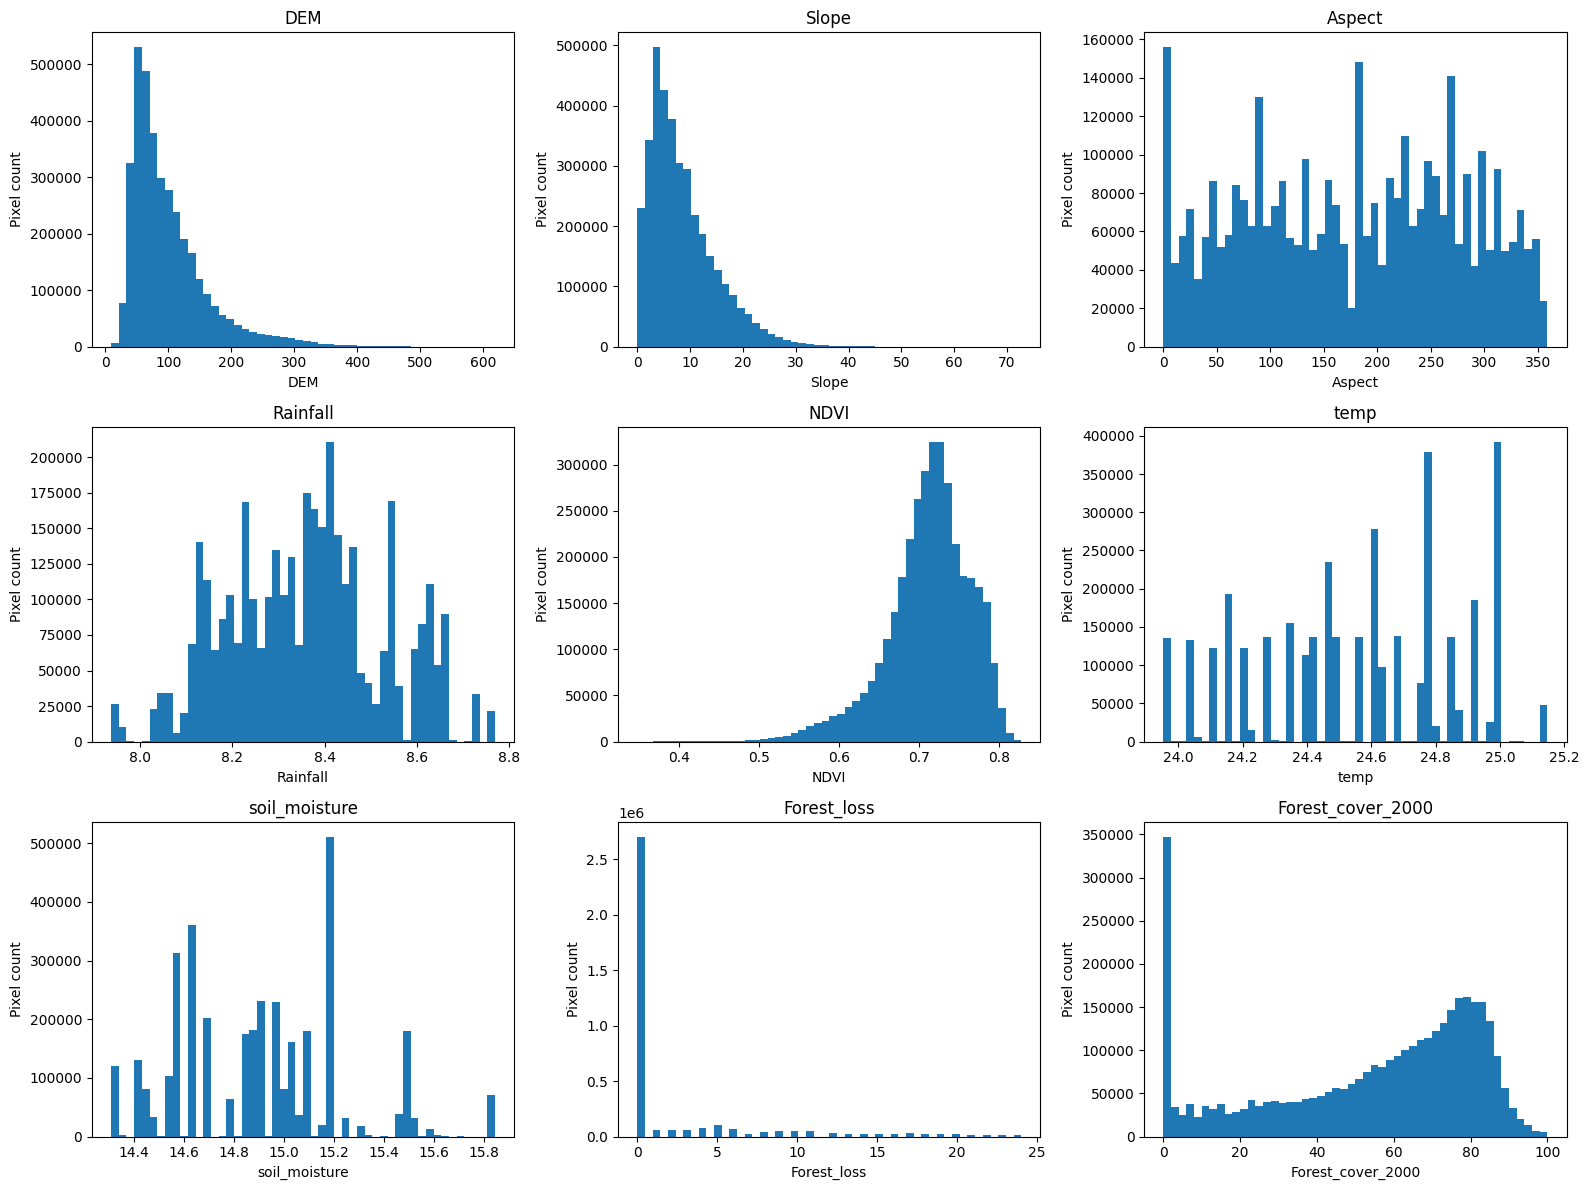

In [ ]:
import matplotlib.pyplot as plt
#EDA
continuous_features = [
    "DEM",
    "Slope",
    "Aspect",
    "Rainfall",
    "NDVI",
    "temp",
    "soil_moisture",
    "Forest_loss",
    "Forest_cover_2000"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, feature in zip(axes.flatten(), continuous_features):

    ax.hist(df_clean[feature], bins=50)

    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("Pixel count")

plt.tight_layout()
plt.show()

LULC
10.0    3308978
20.0          8
30.0      25584
40.0     263852
50.0       5004
60.0       2481
80.0       1680
90.0       3486
Name: count, dtype: int64


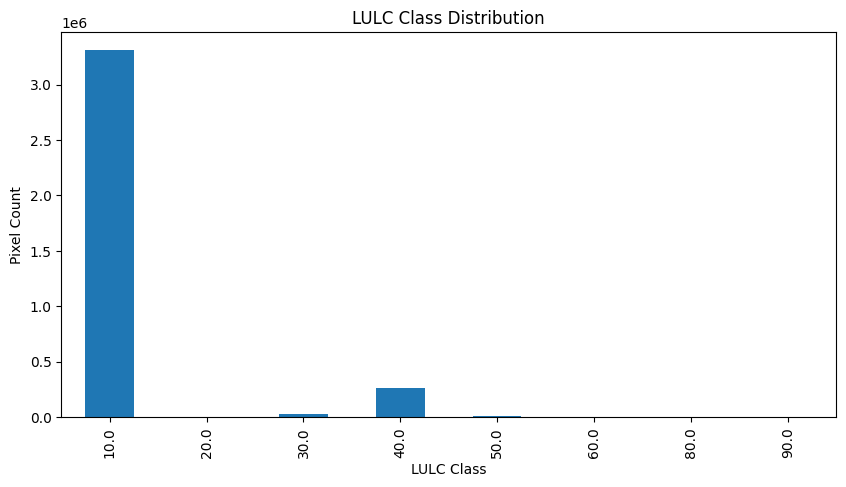

In [ ]:
#We need to do LULC separately because its catagorical:

lulc_counts = df_clean["LULC"].value_counts().sort_index()

print(lulc_counts)

plt.figure(figsize=(10, 5))

lulc_counts.plot(kind="bar")

plt.title("LULC Class Distribution")
plt.xlabel("LULC Class")
plt.ylabel("Pixel Count")

plt.show()

Then comes the really interesting part: correlation

After those two plots, we'll examine:

DEM
Slope
Aspect
Rainfall
NDVI
Temperature
Soil moisture
Forest loss
Forest cover

and determine which variables are related.

In [5]:
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path
from rasterio.warp import reproject, Resampling

# ============================================
# FEATURE ENGINEERING — STEP 1
# ============================================

# Ensure aligned_folder exists
aligned_folder = Path("/content/Khagrachari_aligned")
aligned_folder.mkdir(exist_ok=True)

# Define reference path and alignment function (copied from previous cells for self-containment)
input_folder = Path("/content")
reference_path = input_folder / "Khagrachari_DEM.tif"

def align_raster(input_path, output_path, reference_path, resampling_method):

    # Open reference raster
    with rasterio.open(reference_path) as ref:

        # Open input raster
        with rasterio.open(input_path) as src:

            # Create output profile based on reference grid
            profile = src.profile.copy()

            profile.update({
                "crs": ref.crs,
                "transform": ref.transform,
                "width": ref.width,
                "height": ref.height
            })

            # Create aligned raster
            with rasterio.open(output_path, "w", **profile) as dst:

                reproject(
                    source=rasterio.band(src, 1),
                    destination=rasterio.band(dst, 1),

                    src_transform=src.transform,
                    src_crs=src.crs,

                    dst_transform=ref.transform,
                    dst_crs=ref.crs,

                    resampling=resampling_method
                )

# List all predictors that need to be aligned
predictors_to_align = [
    "Khagrachari_DEM.tif",
    "Khagrachari_Slope.tif",
    "Khagrachari_Aspect.tif",
    "Khagrachari_Rainfall.tif",
    "Khagrachari_NDVI.tif",
    "Khagrachari_temp.tif",
    "Khagrachari_soil_moisture.tif",
    "Khagrachari_Forest_loss.tif",
    "Khagrachari_Forest_cover_2000.tif",
    "Khagrachari_LULC.tif"
]

# Perform alignment for all predictors to ensure they are in aligned_folder and have uniform dimensions
for filename in predictors_to_align:
    input_path = input_folder / filename
    output_path = aligned_folder / filename

    # Determine resampling method based on layer type
    if filename == "Khagrachari_LULC.tif":
        resampling_method = Resampling.nearest
    else: # All other layers are continuous (or treated as such)
        resampling_method = Resampling.bilinear

    # Align and write to aligned_folder
    align_raster(input_path, output_path, reference_path, resampling_method)
    print(f"Ensured alignment for: {filename}")


# Now, we are confident all files are in aligned_folder and are aligned.
predictors = [
    "Khagrachari_DEM.tif",
    "Khagrachari_Slope.tif",
    "Khagrachari_Aspect.tif",
    "Khagrachari_Rainfall.tif",
    "Khagrachari_NDVI.tif",
    "Khagrachari_temp.tif",
    "Khagrachari_soil_moisture.tif",
    "Khagrachari_Forest_loss.tif",
    "Khagrachari_Forest_cover_2000.tif",
    "Khagrachari_LULC.tif"
]

data = {}

for filename in predictors:
    # Explicitly read from aligned_folder, as they should all be there and aligned
    path = aligned_folder / filename

    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")

        # Convert raster NoData to NaN
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan

        data[filename.replace("Khagrachari_", "").replace(".tif", "")] = arr.flatten()

df = pd.DataFrame(data)

df_clean = df.dropna().copy()

df_ml = df_clean.copy()

# -----------------------------
# 1. Aspect transformation
# ------------------------------

aspect_rad = np.deg2rad(df_ml["Aspect"])

df_ml["Aspect_sin"] = np.sin(aspect_rad)
df_ml["Aspect_cos"] = np.cos(aspect_rad)


# -----------------------------
# 2. Forest-loss occurrence
# ------------------------------

df_ml["Forest_loss_binary"] = (
    df_ml["Forest_loss"] > 0
).astype("int8")


# -----------------------------
# 3. Inspect new features
# ------------------------------

print("New shape:")
print(df_ml.shape)

print("\nNew columns:")
print(df_ml.columns.tolist())

print("\nAspect transformation:")
print(
    df_ml[
        ["Aspect", "Aspect_sin", "Aspect_cos"]
    ].head()
)

print("\nForest loss:")
print(
    df_ml["Forest_loss_binary"].value_counts()
)

print("\nMissing values:")
print(df_ml.isna().sum())

Ensured alignment for: Khagrachari_DEM.tif
Ensured alignment for: Khagrachari_Slope.tif
Ensured alignment for: Khagrachari_Aspect.tif
Ensured alignment for: Khagrachari_Rainfall.tif
Ensured alignment for: Khagrachari_NDVI.tif
Ensured alignment for: Khagrachari_temp.tif
Ensured alignment for: Khagrachari_soil_moisture.tif
Ensured alignment for: Khagrachari_Forest_loss.tif
Ensured alignment for: Khagrachari_Forest_cover_2000.tif
Ensured alignment for: Khagrachari_LULC.tif
New shape:
(3602901, 13)

New columns:
['DEM', 'Slope', 'Aspect', 'Rainfall', 'NDVI', 'temp', 'soil_moisture', 'Forest_loss', 'Forest_cover_2000', 'LULC', 'Aspect_sin', 'Aspect_cos', 'Forest_loss_binary']

Aspect transformation:
          Aspect  Aspect_sin  Aspect_cos
2736   21.664705    0.369174    0.929360
2737  354.328613   -0.098823    0.995105
4549  328.747040   -0.518818    0.854885
4550  317.687531   -0.673173    0.739485
4551    0.000000    0.000000    1.000000

Forest loss:
Forest_loss_binary
0    2691321
1   

Raw TIFFs ✅

      ↓
Alignment ✅

      ↓
Cleaning ✅

      ↓
Feature Engineering ✅

      ↓
Feature Selection  ← TODAY

      ↓
Target Variable

      ↓
Train/Test Split

      ↓
Feature Scaling (if needed)

      ↓
Random Forest

      ↓
Evaluation

      ↓
Feature Importance

      ↓
Prediction


In [6]:
#Feature Selection for Khagrrachhari for Stage A:
'''
DEM
Slope
Aspect
Rainfall
NDVI
temp
soil_moisture
Forest_loss
Forest_cover_2000
LULC
Aspect_sin
Aspect_cos
Forest_loss_binary'''

#For random Forest model:

features = [
    "DEM",
    "Slope",
    "Rainfall",
    "NDVI",
    "temp",
    "soil_moisture",
    "Forest_cover_2000",
    "LULC",
    "Aspect_sin",
    "Aspect_cos"
]

#Temporary target:

target = "Forest_loss_binary"

# For X and y:
#Creating X and y:

X = df_ml[features]

y = df_ml[target]

print("X shape = ", X.shape)
print("y shape = ",y.shape)

X shape =  (3602901, 10)
y shape =  (3602901,)


In [7]:
#Feature Selection for Khagrrachhari for Stage A:
'''
DEM
Slope
Aspect
Rainfall
NDVI
temp
soil_moisture
Forest_loss
Forest_cover_2000
LULC
Aspect_sin
Aspect_cos
Forest_loss_binary'''

#For random Forest model:

features = [
    "DEM",
    "Slope",
    "Rainfall",
    "NDVI",
    "temp",
    "soil_moisture",
    "Forest_cover_2000",
    "LULC",
    "Aspect_sin",
    "Aspect_cos"
]

#Temporary target:

target = "Forest_loss_binary"

# For X and y:
#Creating X and y:

X = df_ml[features]

y = df_ml[target]

print(X.shape)
print(y.shape)

(3602901, 10)
(3602901,)


In [8]:
#Train/Test Split:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("Training labels:", y_train.shape)
print("Testing labels :", y_test.shape)

Training set: (2882320, 10)
Testing set : (720581, 10)
Training labels: (2882320,)
Testing labels : (720581,)


In [9]:
df_sample = df_ml.sample(
    n=200000,
    random_state=42
)

# Using the features and target defined in the previous cell
X = df_sample[features]
y = df_sample[target]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
#Random Forest :

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print(" Random Forest training completed!")

 Random Forest training completed!


In [18]:
y_pred = rf.predict(X_test)

In [12]:
y_pred = rf.predict(X_test)

print("Prediction completed!")
print(y_pred[:20])

Prediction completed!
[0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0]


In [13]:
#Evaluating model

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:
0.775775

Confusion Matrix:
[[28032  1901]
 [ 7068  2999]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.94      0.86     29933
           1       0.61      0.30      0.40     10067

    accuracy                           0.78     40000
   macro avg       0.71      0.62      0.63     40000
weighted avg       0.75      0.78      0.75     40000



In [14]:
#Feature importance

import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

             Feature  Importance
3               NDVI    0.168669
0                DEM    0.139528
1              Slope    0.136129
6  Forest_cover_2000    0.134239
8         Aspect_sin    0.117270
9         Aspect_cos    0.116450
2           Rainfall    0.072127
4               temp    0.054228
5      soil_moisture    0.051275
7               LULC    0.010086


In [16]:
#Model evaluation

y_pred = rf.predict(X_test)

print("Prediction completed!")
print(y_pred[:20])

Prediction completed!
[0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0]


In [15]:
#Evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:")
print(accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:
0.775775

Confusion Matrix:
[[28032  1901]
 [ 7068  2999]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.94      0.86     29933
           1       0.61      0.30      0.40     10067

    accuracy                           0.78     40000
   macro avg       0.71      0.62      0.63     40000
weighted avg       0.75      0.78      0.75     40000



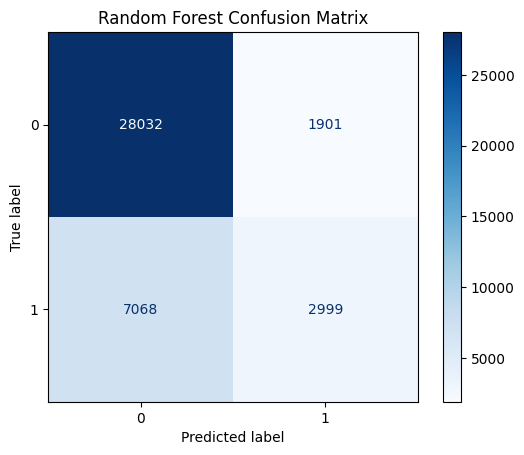

In [17]:
# Visualize the Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()